<a href="https://colab.research.google.com/github/sarveshrastogi1/Meibomian-Gland/blob/main/meibo_extraction_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Objective image analysis of the meibomian gland area
#Arita

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/images.zip

Archive:  /content/drive/MyDrive/images.zip
   creating: images/
  inflating: images/1.png            
  inflating: images/10.png           
  inflating: images/11.png           
  inflating: images/12.png           
  inflating: images/13.png           
  inflating: images/14.png           
  inflating: images/15.png           
  inflating: images/16.png           
  inflating: images/17.png           
  inflating: images/18.png           
  inflating: images/19.png           
  inflating: images/1e0bcf71_1682659845069_1682659845069_5_M_1682659895870_r_le_60_Lower_lid_Meibography.json  
  inflating: images/1e0bcf71_1682659845069_1682659845069_5_M_1682659895870_r_le_60_Lower_lid_Meibography.png  
  inflating: images/1e0bcf71_1682660162156_1682660162156_6_M_1682660210772_r_re_55_Lower_lid_Meibography.png  
  inflating: images/1e0bcf71_1682686651674_1682687158714_3_F_1682687189992_r_le_50_Lower_lid_Meibography.png  
  inflating: images/1e0bcf71_1682686651674_1683090143679_11_M_1683090421

In [ ]:
!unzip /content/drive/MyDrive/clahe_images.zip

Archive:  /content/drive/MyDrive/clahe_images.zip
   creating: clahe_images/
  inflating: clahe_images/1.png      
  inflating: clahe_images/10.png     
  inflating: clahe_images/11.png     
  inflating: clahe_images/12.png     
  inflating: clahe_images/13.png     
  inflating: clahe_images/14.png     
  inflating: clahe_images/15.png     
  inflating: clahe_images/16.png     
  inflating: clahe_images/17.png     
  inflating: clahe_images/18.png     
  inflating: clahe_images/19.png     
  inflating: clahe_images/1e0bcf71_1682659845069_1682659845069_5_M_1682659895870_r_le_60_Lower_lid_Meibography.png  
  inflating: clahe_images/1e0bcf71_1682660162156_1682660162156_6_M_1682660210772_r_re_55_Lower_lid_Meibography.png  
  inflating: clahe_images/1e0bcf71_1682686651674_1682687158714_3_F_1682687189992_r_le_50_Lower_lid_Meibography.png  
  inflating: clahe_images/1e0bcf71_1682686651674_1683090143679_11_M_1683090421578_r_le_60_Lower_lid_Meibography.png  
  inflating: clahe_images/1e0bcf71_1

In [ ]:
!unzip /content/new_mask1.zip

Archive:  /content/new_mask1.zip
   creating: new_mask1/
  inflating: new_mask1/1.png         
  inflating: new_mask1/10.png        
  inflating: new_mask1/11.png        
  inflating: new_mask1/12.png        
  inflating: new_mask1/13.png        
  inflating: new_mask1/14.png        
  inflating: new_mask1/15.png        
  inflating: new_mask1/16.png        
  inflating: new_mask1/17.png        
  inflating: new_mask1/18.png        
  inflating: new_mask1/19.png        
  inflating: new_mask1/1e0bcf71_1682659845069_1682659845069_5_M_1682659895870_r_le_60_Lower_lid_Meibography.png  
  inflating: new_mask1/1e0bcf71_1682660162156_1682660162156_6_M_1682660210772_r_re_55_Lower_lid_Meibography.png  
  inflating: new_mask1/1e0bcf71_1682686651674_1682687158714_3_F_1682687189992_r_le_50_Lower_lid_Meibography.png  
  inflating: new_mask1/1e0bcf71_1682686651674_1683090143679_11_M_1683090421578_r_le_60_Lower_lid_Meibography.png  
  inflating: new_mask1/1e0bcf71_1682686651674_1683090143679_11_M_168

In [ ]:
import cv2
import os
import numpy as np

# Paths to the folders containing the images and masks
image_folder = 'images'
mask_folder = 'new_mask1'
output_folder = 'seg_images_OG'

# Ensure output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Get the list of all images and masks (assuming same filenames for images and masks)
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg') or f.endswith('.png')]

# Loop through each image and apply its mask
for image_file in image_files:
    # Load the image
    image_path = os.path.join(image_folder, image_file)
    image = cv2.imread(image_path)

    # Load the corresponding mask (assuming same name as image)
    mask_path = os.path.join(mask_folder, image_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None or image is None:
        print(f"Could not load image or mask for {image_file}")
        continue

    # Ensure the mask is binary
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Convert mask to 3 channels if the image is in color
    if len(image.shape) == 3:  # If the image has 3 channels (color image)
        binary_mask_3ch = cv2.merge([binary_mask, binary_mask, binary_mask])
    else:
        binary_mask_3ch = binary_mask  # For grayscale image

    # Apply the mask to the image
    segmented_image = cv2.bitwise_and(image, binary_mask_3ch)

    # Save the result in the output folder
    output_path = os.path.join(output_folder, image_file)
    cv2.imwrite(output_path, segmented_image)
    print(f"Segmented image saved as {output_path}")

print("Batch segmentation completed.")


Segmented image saved as seg_images_OG/1e0bcf71_1686897642110_1686897642110_24_F_1686897934856_r_le_32.5_Upper_lid_Meibography.png
Segmented image saved as seg_images_OG/1e0bcf71_1686828824064_1686828824064_33_M_1686829054795_r_le_42.5_Lower_lid_Meibography.png
Segmented image saved as seg_images_OG/85a51b6f_1643264539580_1643264539580_45_F_1643264748920_r_re_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images_OG/dcf9f585_1640321430062_1640321430062_26_F_1640321534999_r_le_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images_OG/1e0bcf71_1683177541540_1683177541540_26_M_1683178169138_r_re_5.26316_Upper_lid_Meibography.png
Segmented image saved as seg_images_OG/dcf9f585_1645761324985_1645761324985_75_M_1645763908159_r_re_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images_OG/85a51b6f_1643186160058_1643186160058_39_F_1643186265197_r_le_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images_OG/1e0bcf71_1686911987611_1686911987611_23_F_1686912085071_r_re_

In [ ]:
import cv2
import os
import numpy as np

# Paths to the folders containing the images and masks
image_folder = 'clahe_images'
mask_folder = 'new_mask1'
output_folder = 'seg_images'

# Ensure output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Get the list of all images and masks (assuming same filenames for images and masks)
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg') or f.endswith('.png')]

# Loop through each image and apply its mask
for image_file in image_files:
    # Load the image
    image_path = os.path.join(image_folder, image_file)
    image = cv2.imread(image_path)

    # Load the corresponding mask (assuming same name as image)
    mask_path = os.path.join(mask_folder, image_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None or image is None:
        print(f"Could not load image or mask for {image_file}")
        continue

    # Ensure the mask is binary
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Convert mask to 3 channels if the image is in color
    if len(image.shape) == 3:  # If the image has 3 channels (color image)
        binary_mask_3ch = cv2.merge([binary_mask, binary_mask, binary_mask])
    else:
        binary_mask_3ch = binary_mask  # For grayscale image

    # Apply the mask to the image
    segmented_image = cv2.bitwise_and(image, binary_mask_3ch)

    # Save the result in the output folder
    output_path = os.path.join(output_folder, image_file)
    cv2.imwrite(output_path, segmented_image)
    print(f"Segmented image saved as {output_path}")

print("Batch segmentation completed.")


Segmented image saved as seg_images/1e0bcf71_1686897642110_1686897642110_24_F_1686897934856_r_le_32.5_Upper_lid_Meibography.png
Segmented image saved as seg_images/1e0bcf71_1686828824064_1686828824064_33_M_1686829054795_r_le_42.5_Lower_lid_Meibography.png
Segmented image saved as seg_images/85a51b6f_1643264539580_1643264539580_45_F_1643264748920_r_re_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images/dcf9f585_1640321430062_1640321430062_26_F_1640321534999_r_le_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images/1e0bcf71_1683177541540_1683177541540_26_M_1683178169138_r_re_5.26316_Upper_lid_Meibography.png
Segmented image saved as seg_images/dcf9f585_1645761324985_1645761324985_75_M_1645763908159_r_re_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images/85a51b6f_1643186160058_1643186160058_39_F_1643186265197_r_le_-_-_-_-_-_Meibography.png
Segmented image saved as seg_images/1e0bcf71_1686911987611_1686911987611_23_F_1686912085071_r_re_12.5_Lower_lid_Meibograp

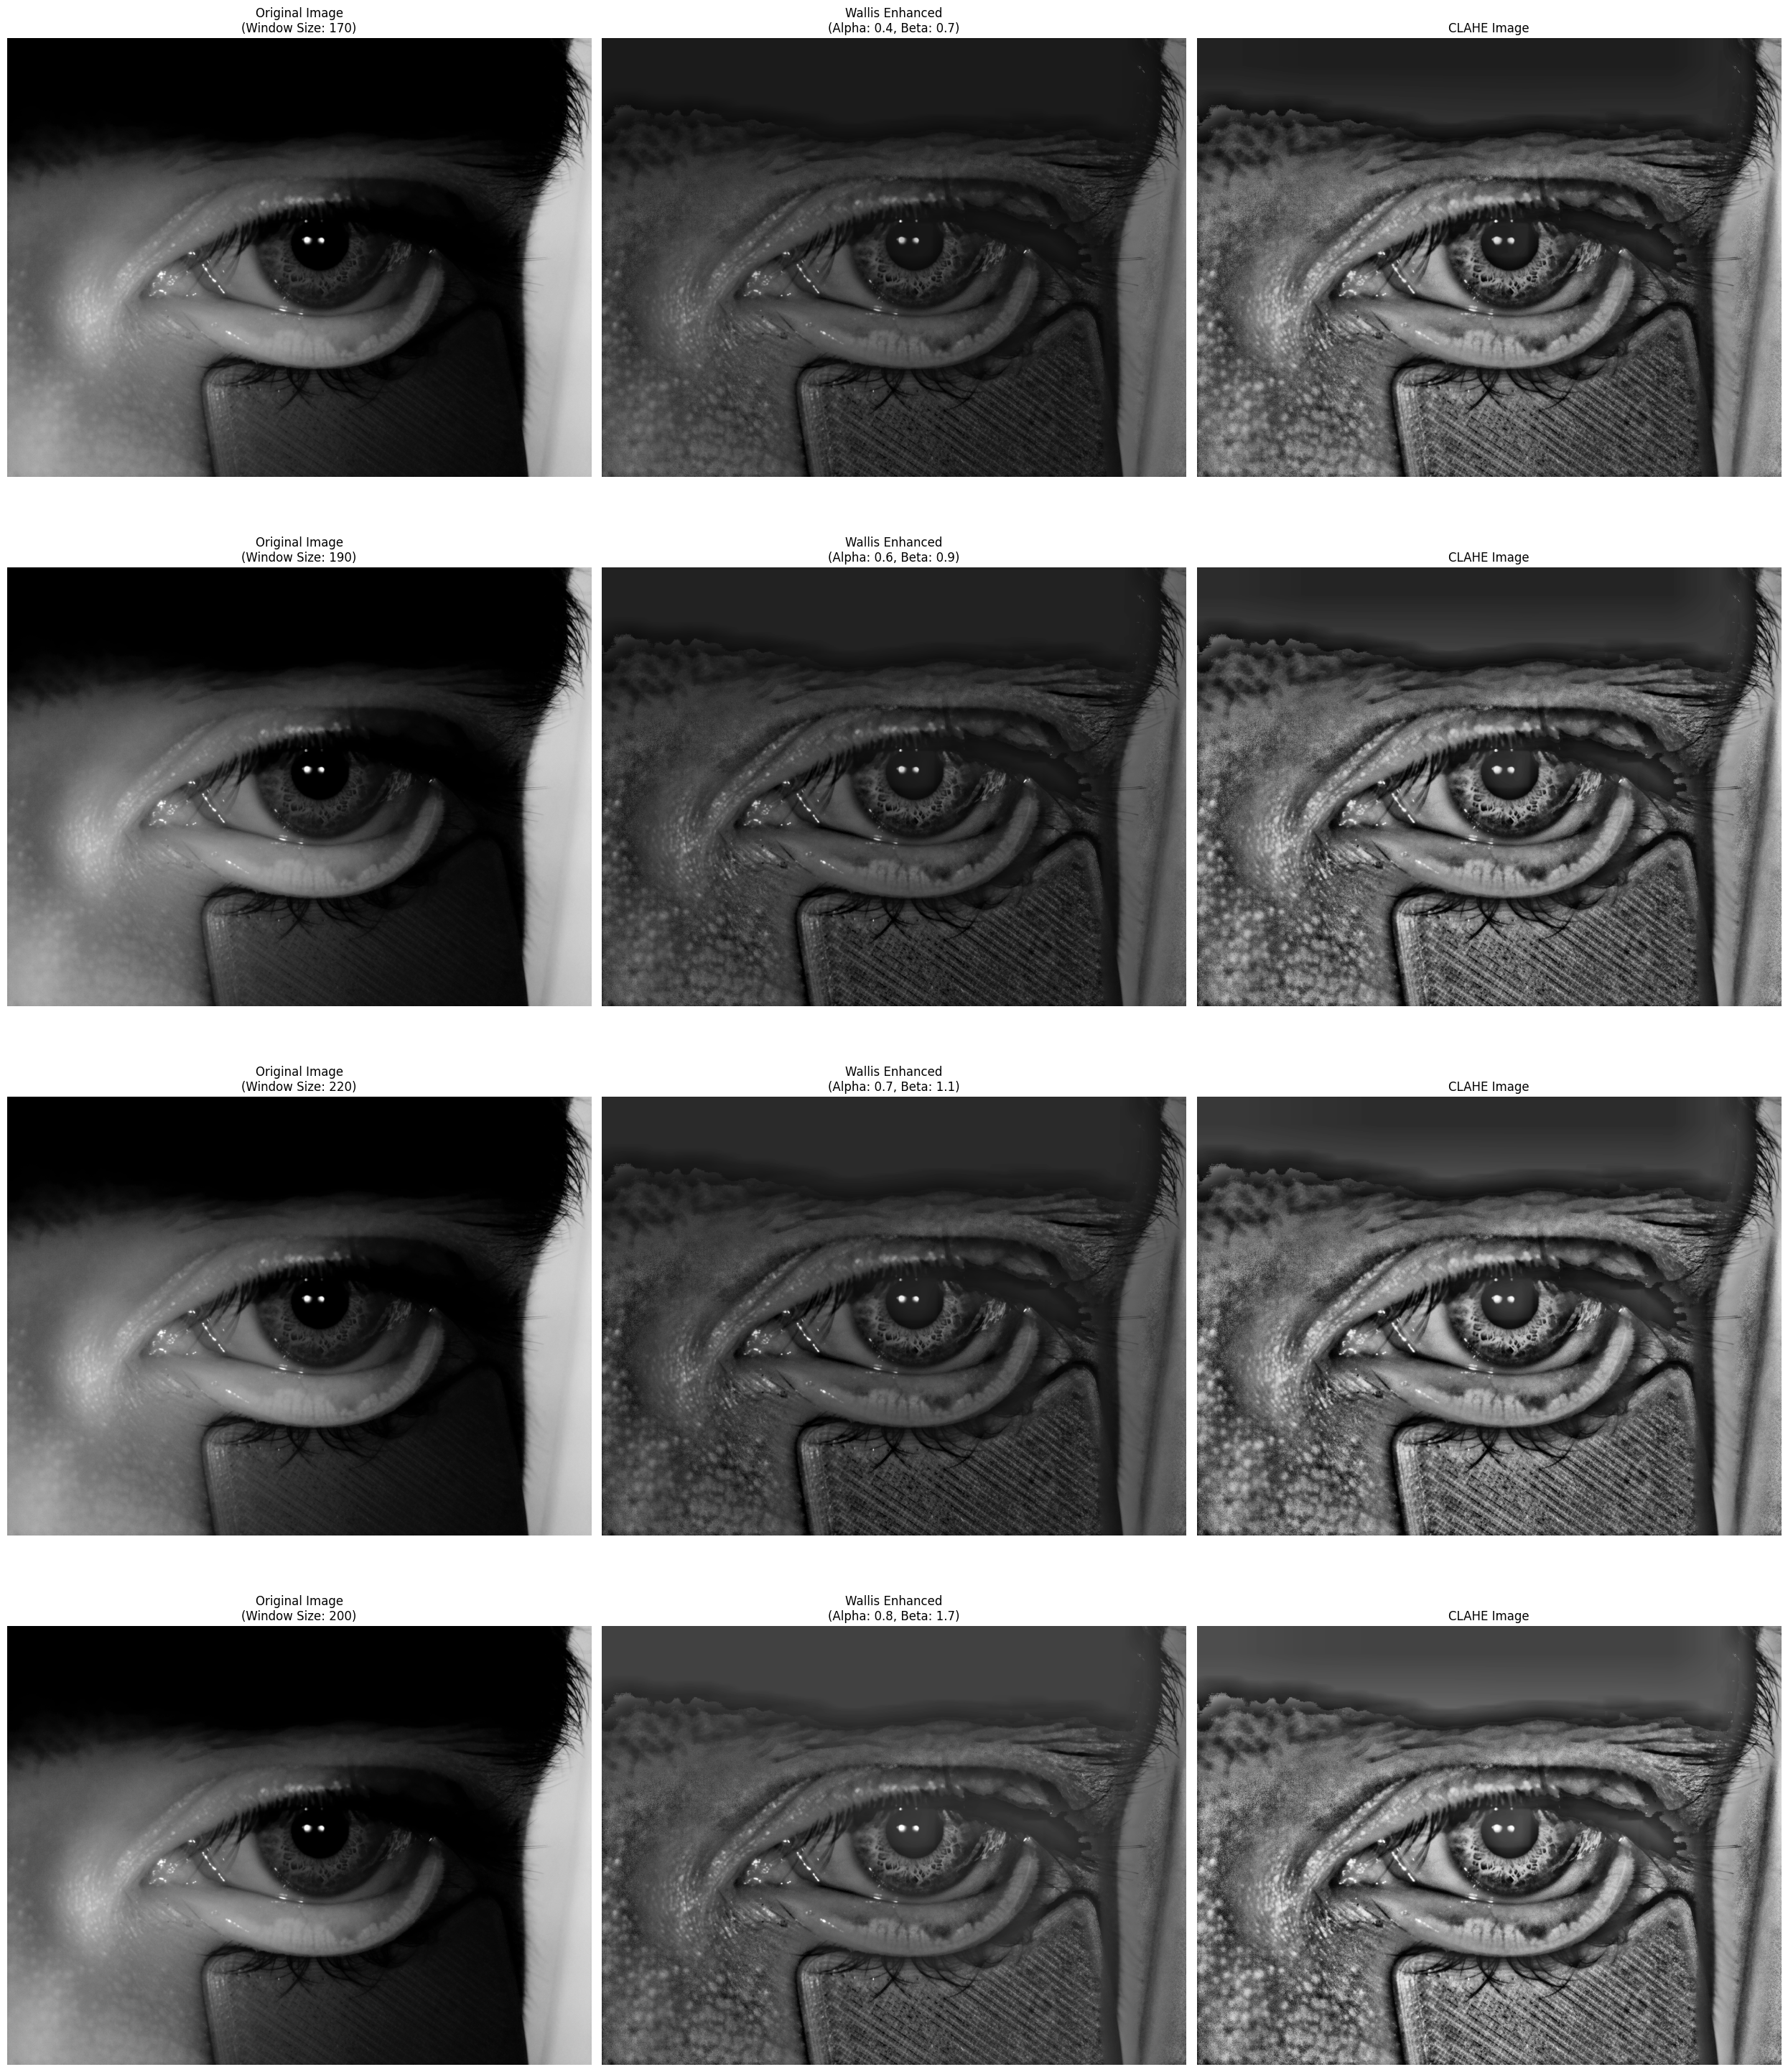

In [ ]:
import cv2
import numpy as np
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

def wallis_filter(image, window_size, alpha, beta):
    """
    Apply Wallis filter for contrast enhancement on the input image.

    Parameters:
    - image: Input image in grayscale.
    - window_size: Size of the local window to calculate local mean and std. Larger values smooth more.
    - alpha: Contrast parameter. Higher values enhance local contrast.
    - beta: Brightness scaling factor. Adjusts contribution of the global mean.

    Returns:
    - enhanced_image: The image after applying the Wallis filter.
    """
    # Convert the image to float32 for precision in calculations
    image = image.astype(np.float32)

    # Global mean and standard deviation
    global_mean = np.mean(image)
    global_std = np.std(image)

    # Compute local mean and local standard deviation (using uniform filter for efficiency)
    local_mean = uniform_filter(image, size=window_size)
    local_sqr_mean = uniform_filter(image**2, size=window_size)
    local_std = np.sqrt(local_sqr_mean - local_mean**2)

    # Avoid division by zero by setting any zero std deviations to a small value
    local_std[local_std < 1e-4] = 1e-4

    # Wallis filter formula
    enhanced_image = alpha * ((image - local_mean) / local_std) * global_std + beta * global_mean + (1 - alpha) * image

    # Clip pixel values to valid range (0-255 for 8-bit images)
    enhanced_image = np.clip(enhanced_image, 0, 255).astype(np.uint8)

    return enhanced_image

# Load the eyelid image (assuming it's in grayscale)
image = cv2.imread('/content/images/1e0bcf71_1683863499960_1683863499960_55_M_1683863851475_r_le_5_Lower_lid_Meibography.png', cv2.IMREAD_GRAYSCALE)

# List of parameter combinations for the Wallis filter
parameter_list = [
    (170, 0.4, 0.7),
    (190, 0.6, 0.9),
    (220, 0.7, 1.1),
    (200, 0.8, 1.7)
]

# Create a figure to display all results
plt.figure(figsize=(25, 30))

for i, (window_size, alpha, beta) in enumerate(parameter_list):
    # Apply the Wallis filter with different parameters
    enhanced_image = wallis_filter(image, window_size, alpha, beta)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_image = clahe.apply(enhanced_image)

    # Display the results
    plt.subplot(len(parameter_list), 3, i * 3 + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'Original Image\n(Window Size: {window_size})')
    plt.axis('off')

    plt.subplot(len(parameter_list), 3, i * 3 + 2)
    plt.imshow(enhanced_image, cmap='gray')
    plt.title(f'Wallis Enhanced\n(Alpha: {alpha}, Beta: {beta})')
    plt.axis('off')

    plt.subplot(len(parameter_list), 3, i * 3 + 3)
    plt.imshow(clahe_image, cmap='gray')
    plt.title('CLAHE Image')
    plt.axis('off')

plt.tight_layout()
plt.show()


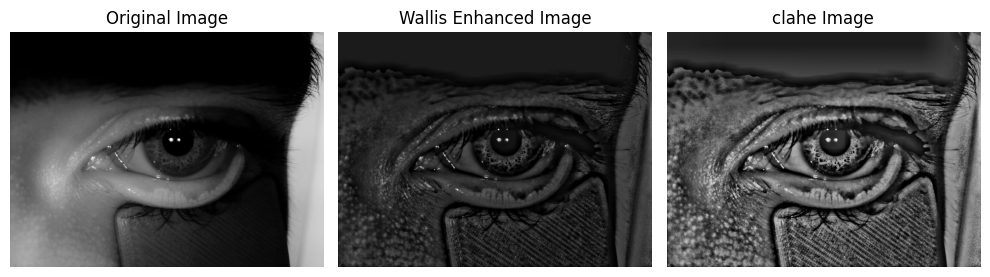

In [ ]:
import cv2
import numpy as np
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

def wallis_filter(image, window_size, alpha, beta):
    """
    Apply Wallis filter for contrast enhancement on the input image.

    Parameters:
    - image: Input image in grayscale.
    - window_size: Size of the local window to calculate local mean and std. Larger values smooth more.
    - alpha: Contrast parameter. Higher values enhance local contrast.
    - beta: Brightness scaling factor. Adjusts contribution of the global mean.

    Returns:
    - enhanced_image: The image after applying the Wallis filter.
    """
    # Convert the image to float32 for precision in calculations
    image = image.astype(np.float32)

    # Global mean and standard deviation
    global_mean = np.mean(image)
    global_std = np.std(image)

    # Compute local mean and local standard deviation (using uniform filter for efficiency)
    local_mean = uniform_filter(image, size=window_size)
    local_sqr_mean = uniform_filter(image**2, size=window_size)
    local_std = np.sqrt(local_sqr_mean - local_mean**2)

    # Avoid division by zero by setting any zero std deviations to a small value
    local_std[local_std < 1e-4] = 1e-4

    # Wallis filter formula
    enhanced_image = alpha * ((image - local_mean) / local_std) * global_std + beta * global_mean + (1 - alpha) * image

    # Clip pixel values to valid range (0-255 for 8-bit images)
    enhanced_image = np.clip(enhanced_image, 0, 255).astype(np.uint8)

    return enhanced_image

# Load the eyelid image (assuming it's in grayscale)
image = cv2.imread('/content/images/1e0bcf71_1683863499960_1683863499960_55_M_1683863851475_r_le_5_Lower_lid_Meibography.png', cv2.IMREAD_GRAYSCALE)


# Apply the Wallis filter
enhanced_image = wallis_filter(image, window_size=170, alpha=0.8, beta=0.7)

clahe= cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_image=clahe.apply(enhanced_image)



# Display using matplotlib
plt.figure(figsize=(10, 5))

# Display the original image
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')


# Display the Wallis enhanced image
plt.subplot(1, 3, 2)
plt.imshow(enhanced_image, cmap='gray')
plt.title('Wallis Enhanced Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clahe_image, cmap='gray')
plt.title('clahe Image')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
cv2.imwrite('clahe_image.png',clahe_image)

True

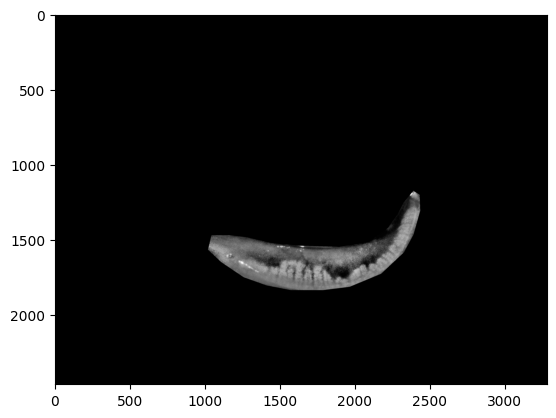

In [ ]:
import cv2
import numpy as np


# Load the original image
image = cv2.imread('/content/clahe_image.png')

# Load the mask image (assuming it is a binary mask)
mask = cv2.imread('/content/new_mask1/1e0bcf71_1683863499960_1683863499960_55_M_1683863851475_r_le_5_Lower_lid_Meibography.png', cv2.IMREAD_GRAYSCALE)

# Ensure that the mask is binary (0 and 255). Normalize the mask to have 0 and 1 values if needed.
_, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# Convert the binary mask to 3 channels to match the image shape (if the image is in color)
binary_mask_3_channel = cv2.merge([binary_mask, binary_mask, binary_mask])

# Apply the mask to the image using bitwise operation
segmented_image = cv2.bitwise_and(image, binary_mask_3_channel)

# Save or display the segmented image
cv2.imwrite('segmented_image.png', segmented_image)

plt.imshow(segmented_image)
plt.show()


(2464, 3280)


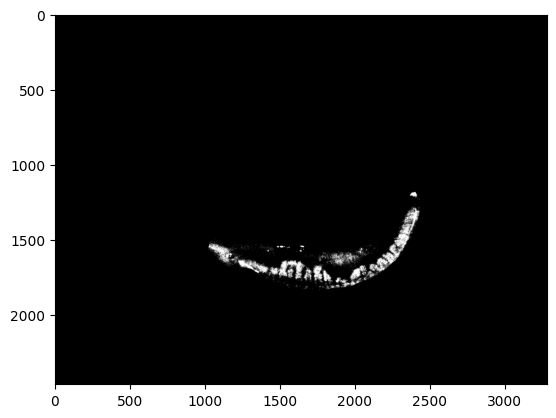

In [ ]:
thres=cv2.imread('/content/segmented_image.png',cv2.IMREAD_GRAYSCALE)
print(thres.shape)
for i in range(thres.shape[0]):
    for j in range(thres.shape[1]):
      if thres[i][j]>140:
        thres[i][j]=255
      else:
        thres[i][j]=0

plt.imshow(thres, cmap='gray')
plt.show()

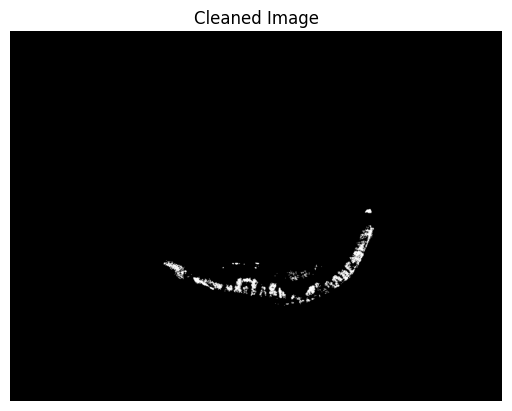

In [ ]:
import cv2
import numpy as np

# Define the kernel size for the morphological operation
kernel = np.ones((3, 3), np.uint8)

# Perform morphological opening (erosion followed by dilation) to remove noise
cleaned_image = cv2.morphologyEx(thres, cv2.MORPH_OPEN, kernel)

plt.imshow(cleaned_image, cmap='gray')
plt.title('Cleaned Image')
plt.axis('off')
plt.show()


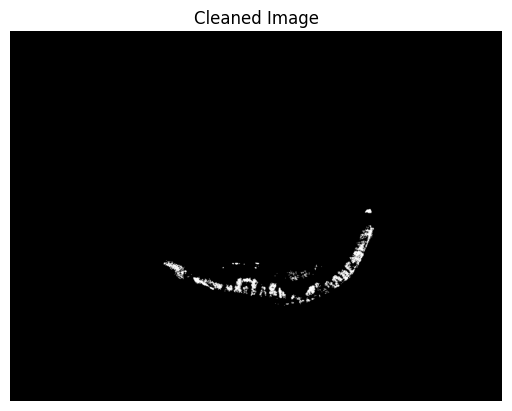

In [ ]:
import cv2
import numpy as np

# Define the kernel size for the morphological operation
kernel = np.ones((3, 3), np.uint8)

# Perform morphological opening (erosion followed by dilation) to remove noise
cleaned_image_2 = cv2.morphologyEx(cleaned_image, cv2.MORPH_OPEN, kernel)

plt.imshow(cleaned_image_2, cmap='gray')
plt.title('Cleaned Image')
plt.axis('off')
plt.show()


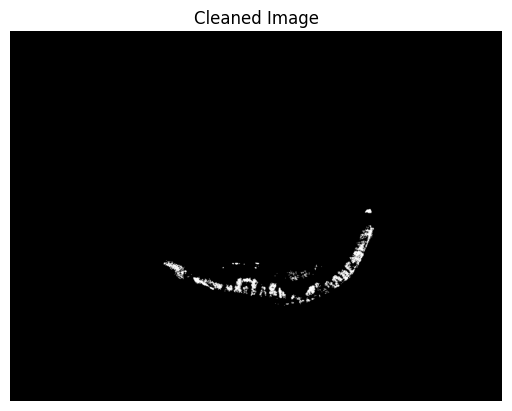

In [ ]:
import cv2
import numpy as np

# Define the kernel size for the morphological operation
kernel = np.ones((3, 3), np.uint8)

# Perform morphological opening (erosion followed by dilation) to remove noise
cleaned_image_3 = cv2.morphologyEx(cleaned_image_2, cv2.MORPH_OPEN, kernel)

plt.imshow(cleaned_image_3, cmap='gray')
plt.title('Cleaned Image')
plt.axis('off')
plt.show()


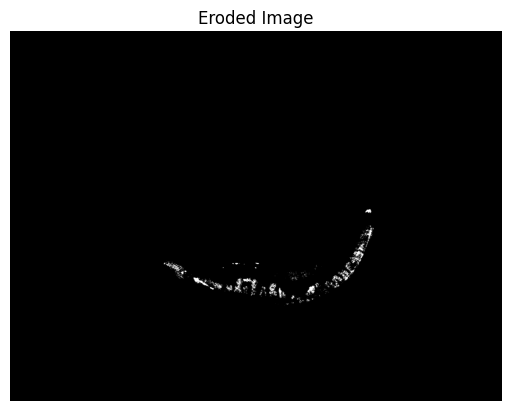

In [ ]:
# Define the kernel size for erosion (a small kernel size will remove smaller spots)
kernel = np.ones((3, 3), np.uint8)

# Apply erosion to the image
eroded_image = cv2.erode(thres, kernel, iterations=1)

# Display the eroded image
plt.imshow(eroded_image, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')
plt.show()

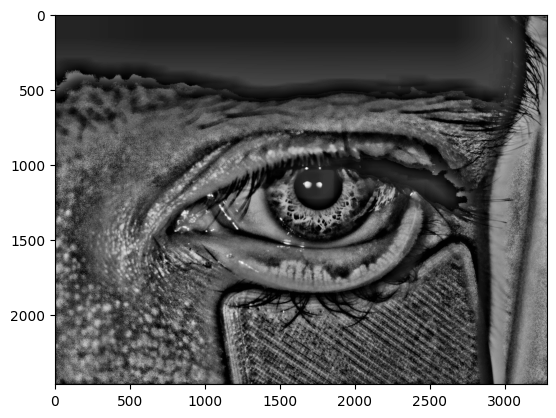

In [ ]:
img=cv2.imread('/content/images/1e0bcf71_1683863499960_1683863499960_55_M_1683863851475_r_le_5_Lower_lid_Meibography.png',cv2.IMREAD_GRAYSCALE)

wallis_filter_img= wallis_filter(img, window_size=170, alpha=0.8, beta=0.7)


plt.imshow(clahe_image, cmap='gray')
plt.show()


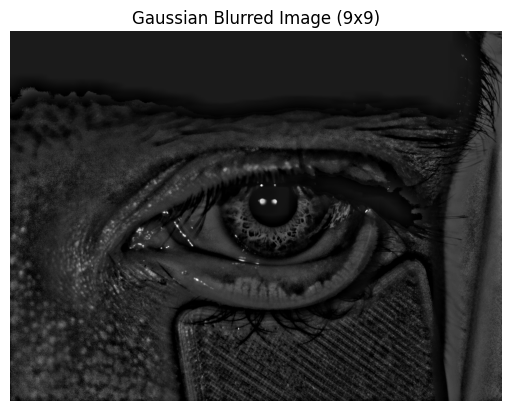

In [ ]:
# Apply Gaussian filter with a 9x9 kernel size
blurred_image = cv2.GaussianBlur(wallis_filter_img, (9, 9), 0.5)

# Display the blurred image using matplotlib
plt.imshow(blurred_image, cmap='gray')
plt.title('Gaussian Blurred Image (9x9)')
plt.axis('off')
plt.show()

In [ ]:
print(max(blurred_image.flatten()))
print(min(blurred_image.flatten()))

255
0


In [ ]:
normalized_raw_image = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
normalised_gaussian_image=cv2.normalize(blurred_image, None, 0, 255, cv2.NORM_MINMAX)

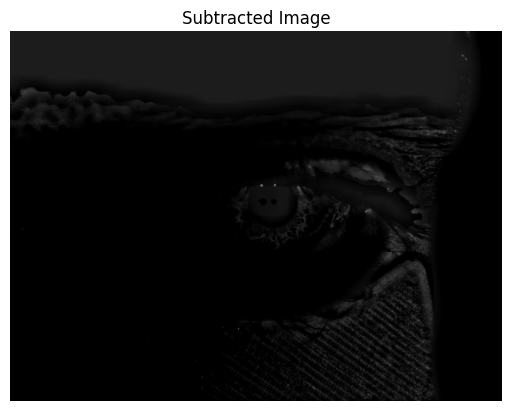

In [ ]:
# Subtract the Gaussian-filtered image from the normalized raw image
subtracted_image = cv2.subtract(normalised_gaussian_image, normalized_raw_image)


plt.imshow(subtracted_image, cmap='gray')
plt.title('Subtracted Image')
plt.axis('off')
plt.show()


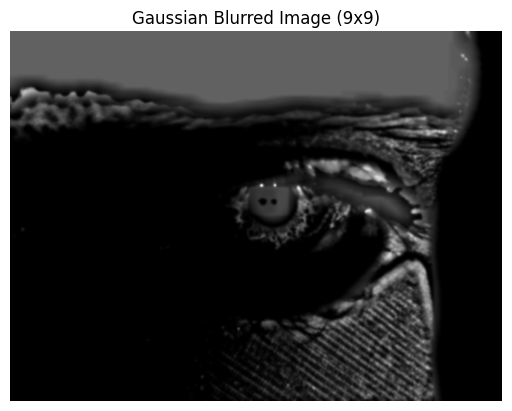

In [ ]:
# Apply Gaussian filter with a 9x9 kernel size
processed_image = cv2.GaussianBlur(subtracted_image, (39, 39), 0.0)

# Display the blurred image using matplotlib
plt.imshow(processed_image, cmap='gray')
plt.title('Gaussian Blurred Image (9x9)')
plt.axis('off')
plt.show()

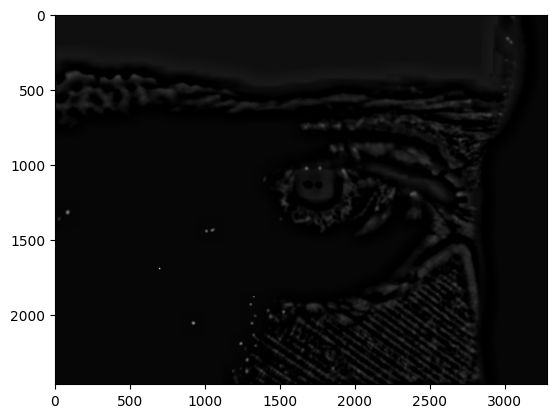

In [ ]:
wallis_2 = wallis_filter(processed_image, window_size=170, alpha=0.8, beta=0.7)

plt.imshow(wallis_2, cmap='gray')
plt.show()

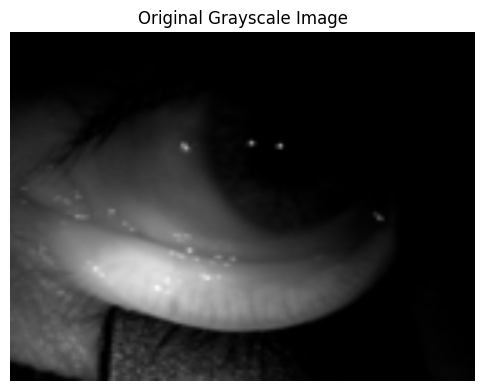

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects, label


# Load the grayscale image
image = cv2.imread('/content/images/85a51b6f_1643184607059_1643184607059_28_M_1643184693201_r_le_-_-_-_-_-_Meibography.png', cv2.IMREAD_GRAYSCALE)

# Display the original image
plt.figure(figsize=(6, 6))
plt.title('Original Grayscale Image')
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()




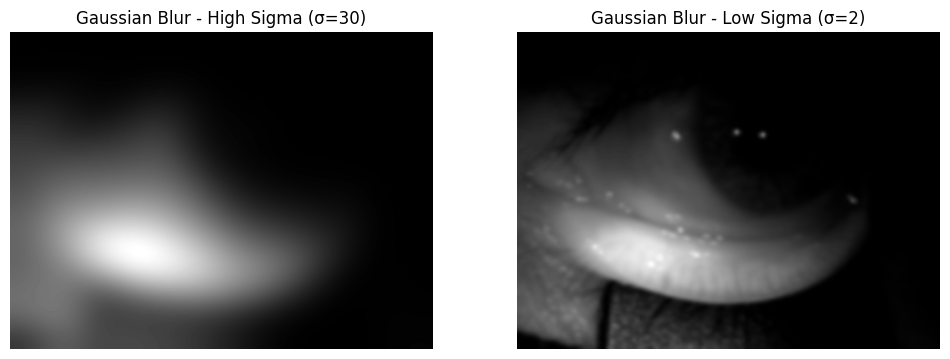

In [ ]:
# Gaussian blur with high sigma (σ = 30)
blur_high = cv2.GaussianBlur(image, (0, 0), 30)

# Gaussian blur with low sigma (σ = 2)
blur_low = cv2.GaussianBlur(image, (0, 0), 2)


# Display the images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(blur_high, cmap='gray')
ax[0].set_title('Gaussian Blur - High Sigma (σ=30)')
ax[0].axis('off')
ax[1].imshow(blur_low, cmap='gray')
ax[1].set_title('Gaussian Blur - Low Sigma (σ=2)')
ax[1].axis('off')

plt.show()


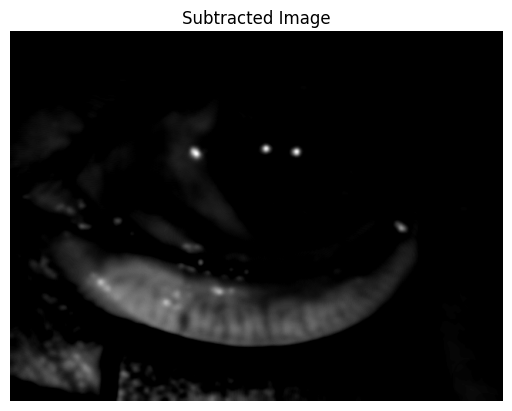

In [ ]:
subtracted_image = cv2.subtract(blur_low, blur_high)

plt.imshow(subtracted_image, cmap='gray')
plt.title('Subtracted Image')
plt.axis('off')
plt.show()

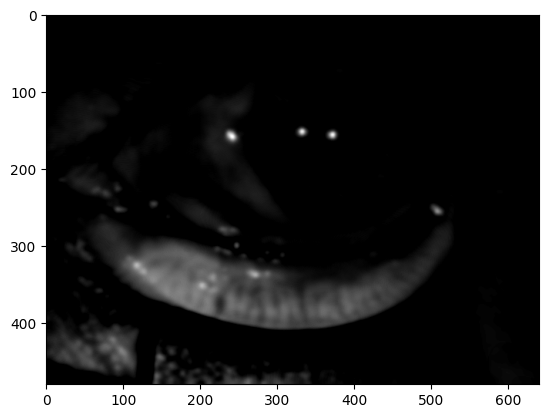

In [ ]:
def wallis_filter(image, window_size, alpha, beta):
    """
    Apply Wallis filter for contrast enhancement on the input image.

    Parameters:
    - image: Input image in grayscale.
    - window_size: Size of the local window to calculate local mean and std. Larger values smooth more.
    - alpha: Contrast parameter. Higher values enhance local contrast.
    - beta: Brightness scaling factor. Adjusts contribution of the global mean.

    Returns:
    - enhanced_image: The image after applying the Wallis filter.
    """
    # Convert the image to float32 for precision in calculations
    image = image.astype(np.float32)

    # Global mean and standard deviation
    global_mean = np.mean(image)
    global_std = np.std(image)

    # Compute local mean and local standard deviation (using uniform filter for efficiency)
    local_mean = uniform_filter(image, size=window_size)
    local_sqr_mean = uniform_filter(image**2, size=window_size)
    local_std = np.sqrt(local_sqr_mean - local_mean**2)

    # Avoid division by zero by setting any zero std deviations to a small value
    local_std[local_std < 1e-4] = 1e-4

    # Wallis filter formula
    enhanced_image = alpha * ((image - local_mean) / local_std) * global_std + beta * global_mean + (1 - alpha) * image

    # Clip pixel values to valid range (0-255 for 8-bit images)
    enhanced_image = np.clip(enhanced_image, 0, 255).astype(np.uint8)

    return enhanced_image

wallis_image=wallis_filter(clahe_image, window_size=170, alpha=0.8, beta=0.7)

plt.imshow(subtracted_image, cmap='gray')
plt.show()

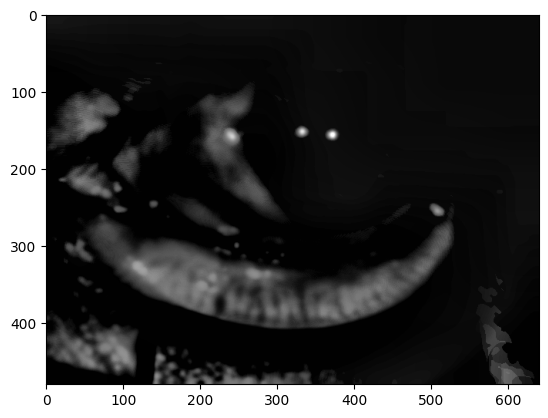

In [ ]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_image = clahe.apply(wallis_image)

plt.imshow(clahe_image, cmap='gray')
plt.show()

In [ ]:
mask= cv2.imread('/content/new_mask1/85a51b6f_1643184607059_1643184607059_28_M_1643184693201_r_le_-_-_-_-_-_Meibography.png', cv2.IMREAD_GRAYSCALE)

print(mask.shape)
print(max(mask.flatten()))
print(min(mask.flatten()))
mask = (mask /255).astype(np.uint8)
#


(480, 640)
255
0


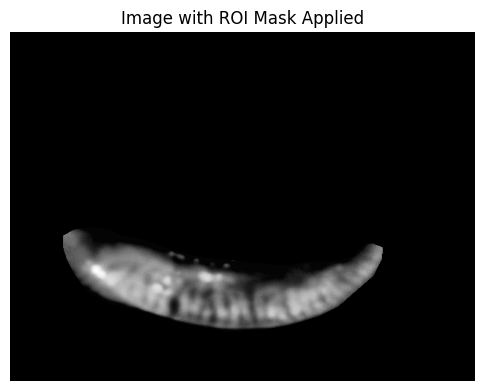

In [ ]:

roi_image =cv2.multiply(clahe_image, mask)

# Display the result
plt.figure(figsize=(6, 6))
plt.title('Image with ROI Mask Applied')
plt.imshow(roi_image, cmap='gray')
plt.axis('off')
plt.show()


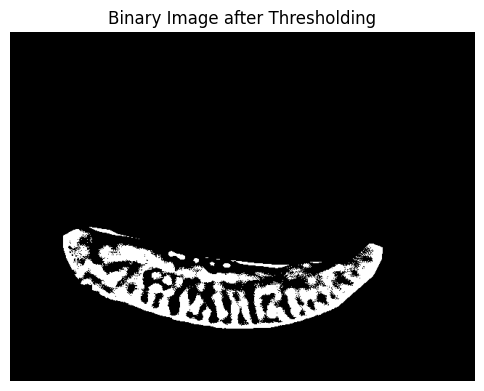

In [ ]:
# Apply adaptive thresholding to binarize the image
binary_image = cv2.adaptiveThreshold(roi_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 31, 0)

# Display the binary image
plt.figure(figsize=(6, 6))
plt.title('Binary Image after Thresholding')
plt.imshow(binary_image, cmap='gray')
plt.axis('off')
plt.show()


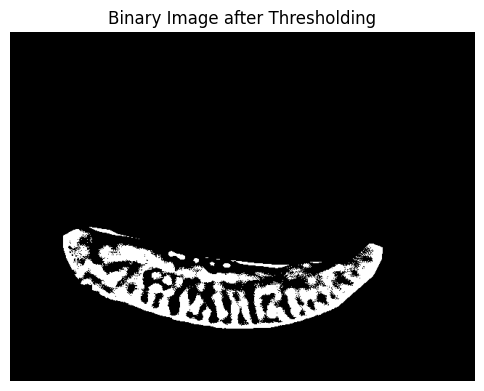

In [ ]:
# Apply adaptive thresholding to binarize the image
binary_image = cv2.adaptiveThreshold(roi_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 31, 0)

# Display the binary image
plt.figure(figsize=(6, 6))
plt.title('Binary Image after Thresholding')
plt.imshow(binary_image, cmap='gray')
plt.axis('off')
plt.show()


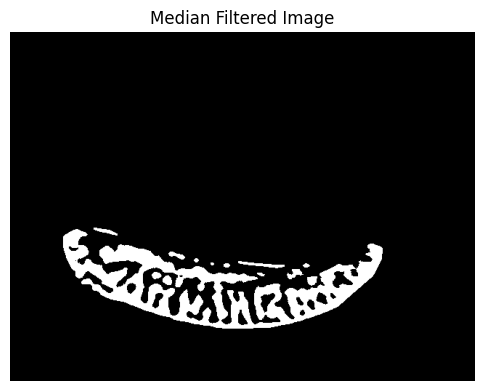

In [ ]:
# Apply median filtering
median_filtered = cv2.medianBlur(binary_image, 5)

# Display the median filtered image
plt.figure(figsize=(6, 6))
plt.title('Median Filtered Image')
plt.imshow(median_filtered, cmap='gray')
plt.axis('off')
plt.show()


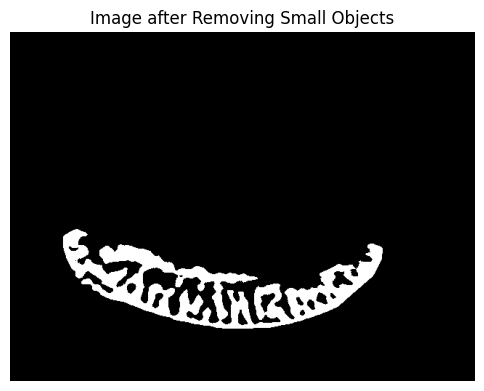

In [ ]:
# Label connected components
labeled_img = label(median_filtered)

# Remove small objects (< 800 px) from the binary image
cleaned_image = remove_small_objects(labeled_img, min_size=800)

# Display the cleaned image
plt.figure(figsize=(6, 6))
plt.title('Image after Removing Small Objects')
plt.imshow(cleaned_image, cmap='gray')
plt.axis('off')
plt.show()


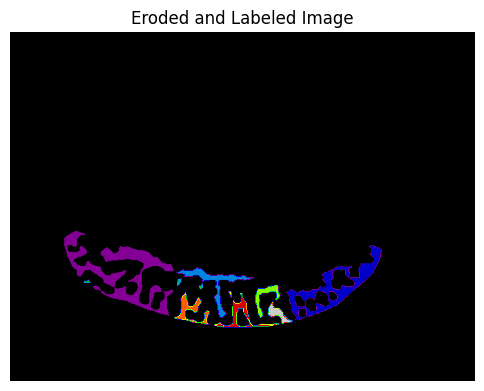

In [ ]:
  # Apply erosion to the rotated image
eroded_image = cv2.erode(cleaned_image.astype(np.uint8), kernel=np.ones((3,3), np.uint8), iterations=2)

# Label the eroded regions
labeled_eroded_image = label(eroded_image)

# Display the eroded and labeled image
plt.figure(figsize=(6, 6))
plt.title('Eroded and Labeled Image')
plt.imshow(labeled_eroded_image, cmap='nipy_spectral')
plt.axis('off')
plt.show()
